In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("loan_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [4]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)


person_age                        float64
person_gender                       int64
person_education                    int64
person_income                     float64
person_emp_exp                      int64
person_home_ownership               int64
loan_amnt                         float64
loan_intent                         int64
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file      int64
loan_status                         int64
dtype: object


In [6]:
df["person_gender"].value_counts().to_frame()

,count
person_gender,
1,24841
0,20159


In [7]:
df["person_education"].value_counts().to_frame()

,count
person_education,
1,13399
0,12028
3,11972
4,6980
2,621


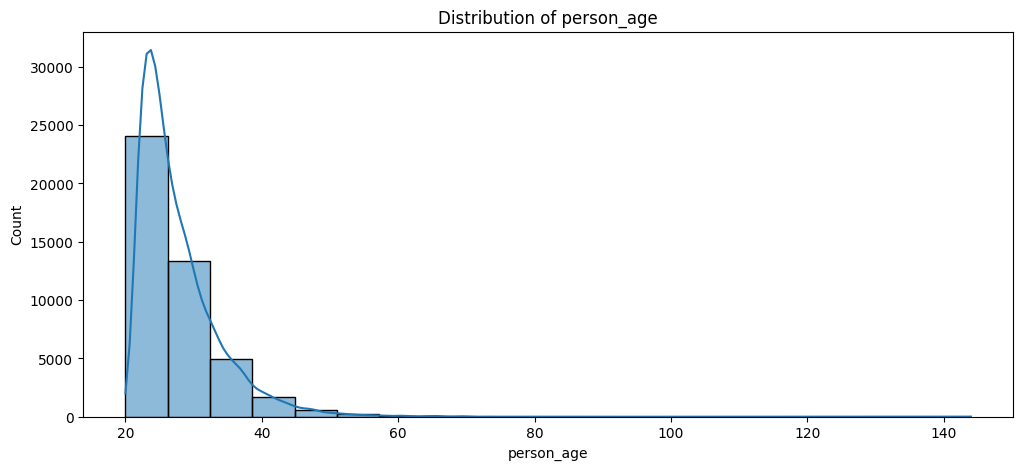

In [8]:
plt.figure(figsize=(12, 5))
sns.histplot(df['person_age'], kde=True, bins=20)
plt.title('Distribution of person_age')
plt.xlabel('person_age')
plt.ylabel('Count')
plt.show()

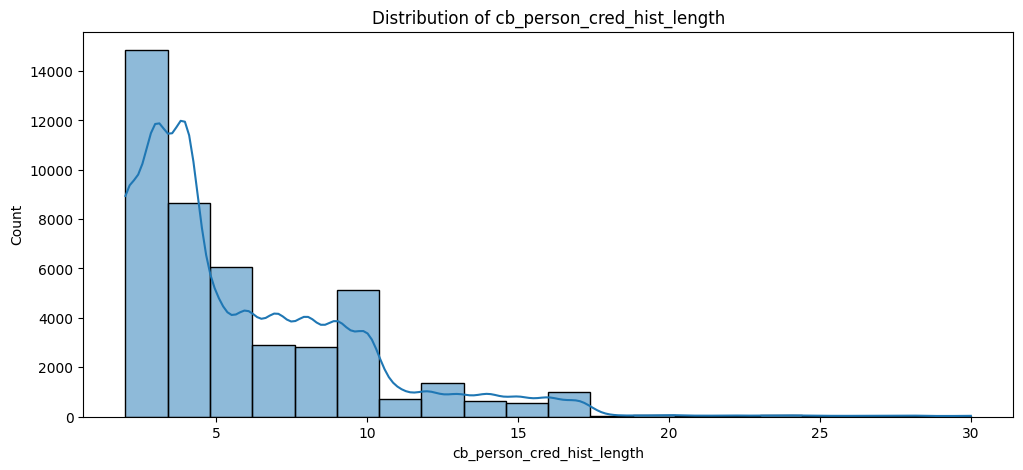

In [9]:
plt.figure(figsize=(12, 5))
sns.histplot(df['cb_person_cred_hist_length'], kde=True, bins=20)
plt.title('Distribution of cb_person_cred_hist_length')
plt.xlabel('cb_person_cred_hist_length')
plt.ylabel('Count')
plt.show()

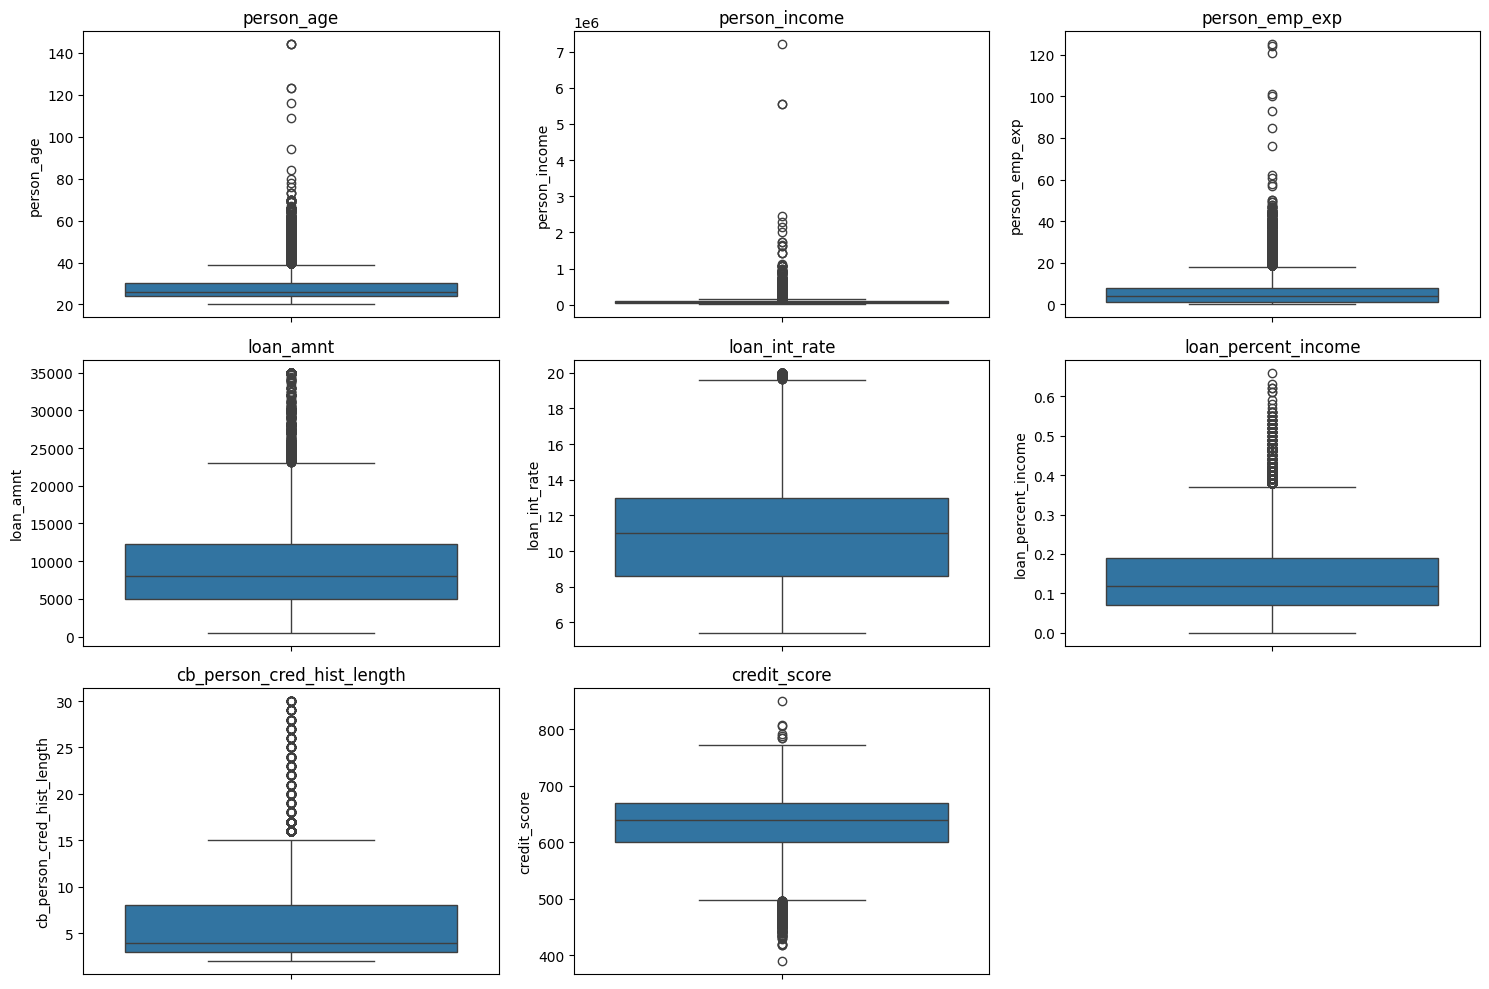

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
outlier_summary = []

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Column": col,
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df = outlier_df.sort_values("Outlier_Count", ascending=False)

print(outlier_df)

                       Column  Outlier_Count  Outlier_Percentage
3                   loan_amnt           2348                5.22
1               person_income           2218                4.93
0                  person_age           2188                4.86
2              person_emp_exp           1724                3.83
6  cb_person_cred_hist_length           1366                3.04
5         loan_percent_income            744                1.65
7                credit_score            467                1.04
4               loan_int_rate            124                0.28


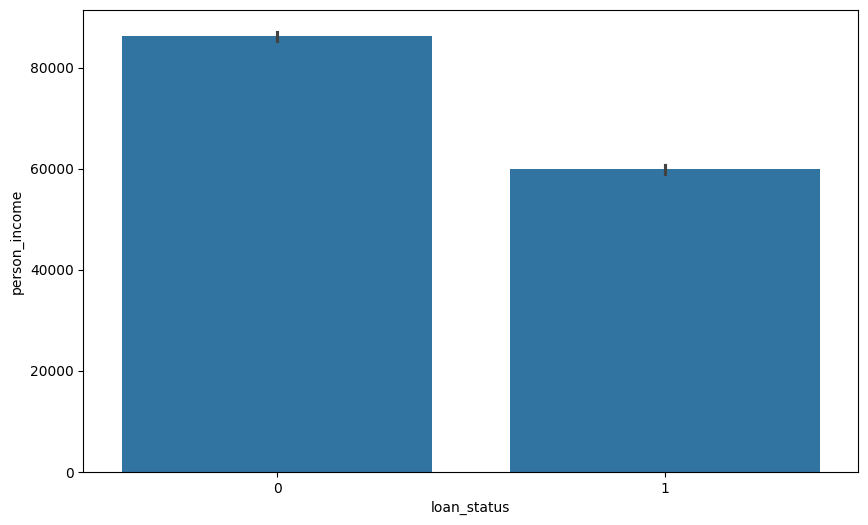

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='loan_status', y="person_income", data=df)
plt.show()

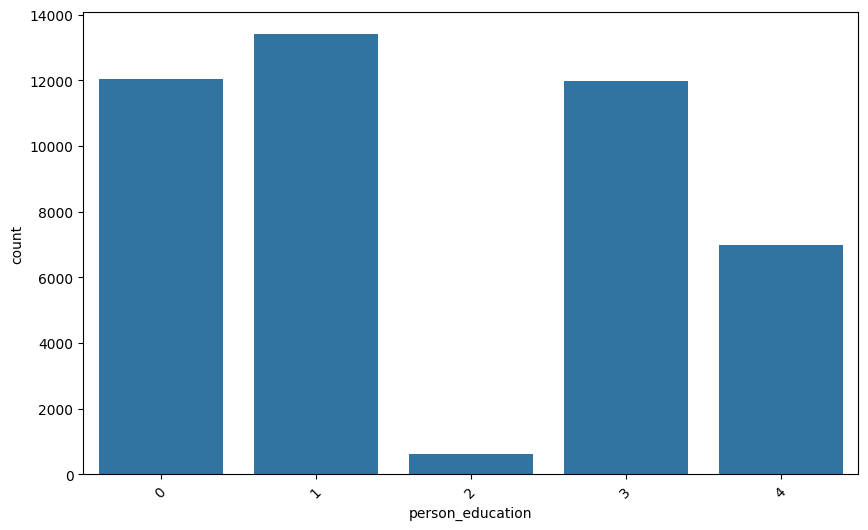

In [13]:
counts = df['person_education'].value_counts().reset_index()
counts.columns = ['person_education', 'count']

plt.figure(figsize=(10,6))
sns.barplot(data=counts, x='person_education', y='count')
plt.xticks(rotation=45)
plt.show()

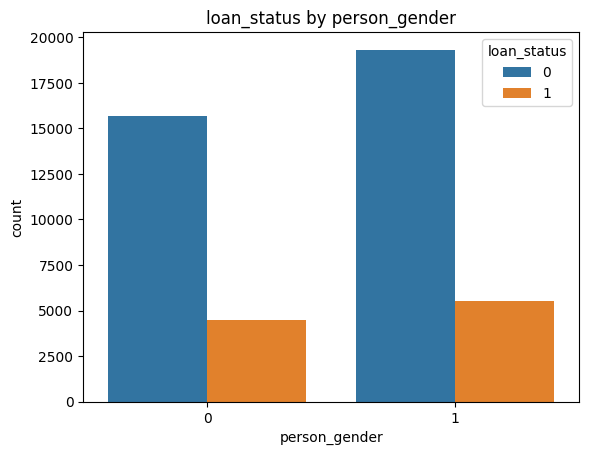

In [14]:
sns.countplot( data=df, x='person_gender', hue='loan_status')
plt.title("loan_status by person_gender")
plt.show()

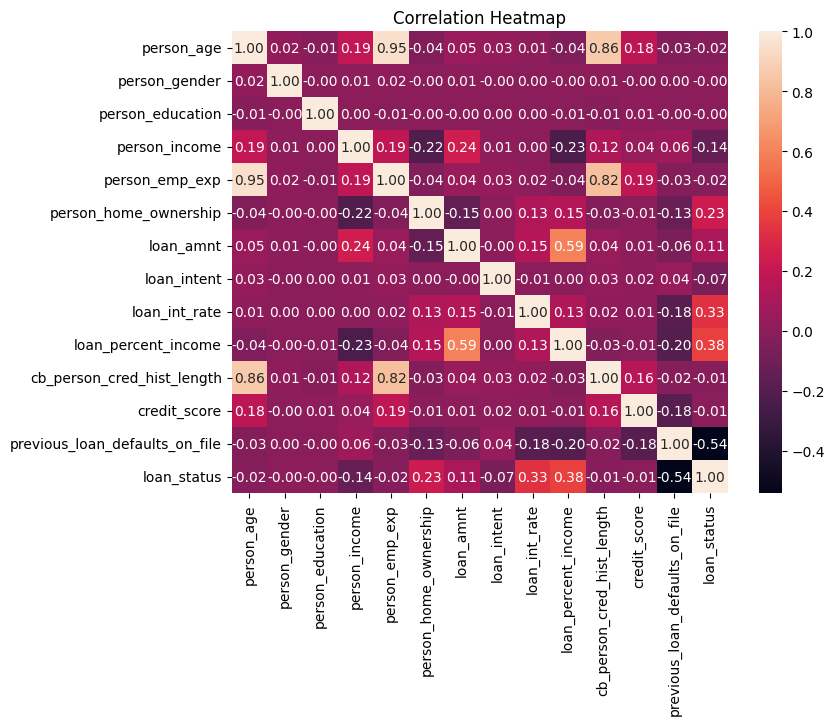

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (36000, 13)
X_test shape: (9000, 13)
y_train shape: (36000,)
y_test shape: (9000,)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report , f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("f1 score :", f1_score(y_test, y_pred))


Accuracy : 0.8806666666666667
Precision: 0.7397540983606558
Recall   : 0.718407960199005
f1 score : 0.7289247854618879


[[6482  508]
 [ 566 1444]]


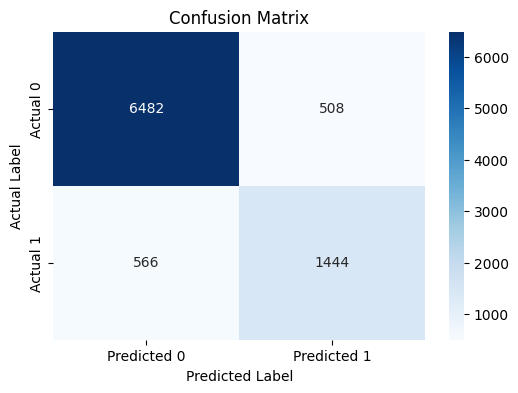

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
print(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8981111111111111
Precision : 0.7731134432783608
Recall : 0.7696517412935323
F1 Score : 0.7713787085514834
ROC-AUC : 0.8523509064121454


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9286666666666666
Precision : 0.8899657924743444
Recall : 0.7766169154228856
F1 Score : 0.8294367693942615
ROC-AUC : 0.9735460038861488


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8918888888888888
Precision : 0.7856749311294766
Recall : 0.709452736318408
F1 Score : 0.7456209150326797
ROC-AUC : 0.9258533156819622


In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9077777777777778
Precision : 0.8288740245261984
Recall : 0.7398009950248756
F1 Score : 0.7818086225026288
ROC-AUC : 0.9569729321916882


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9338888888888889
Precision : 0.8880965441579813
Recall : 0.8054726368159204
F1 Score : 0.8447691103574224
ROC-AUC : 0.9777401974391278
